In [1]:
from pathlib import Path
import warnings

import pandas as pd
import numpy as np

import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from utils.conv_clustering import count_genus_prevalence, sample_violin_plot

# Specify settings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# Plotting params
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["font.family"] = "Arial"

In [2]:
# Base directory of the files
base_dir = Path("..").resolve()

# Directories containing the processed files
processed_dir = base_dir / "2_processed_data" / "3_discovery_convergence"
conv_dir = base_dir / "2_processed_data" / "6_combined_convergence"

# Output directories for the figures and tables
figures_dir = base_dir / "3_figures" / "Figures"
tables_dir = base_dir / "3_figures" / "Tables"
suppl_dir = base_dir / "3_figures" / "Supplementary"

# 1. Discovery dataset: convergent TCRs overview

## Figure 1D/1E. Number of convergent TCRs and cluster characterastics

### Load the data and add genus prevalence

In [3]:
# How many TCRs were there originally for the convergence calculations?
data_alpha = pd.read_csv(processed_dir / "TRA_dataframe.csv")
data_beta = pd.read_csv(processed_dir / "TRB_dataframe.csv")
together = pd.concat([data_alpha, data_beta])
together["disc_celltype"] = together["repertoire_id"].str.split(r"[_-]").str[2]
together["group"] = together["chain"] + "_" + together["disc_celltype"]

# Load convergence results
final_conv = pd.read_csv(conv_dir / "0_combined_final_sign_interactions.csv")
overview_df = pd.read_csv(conv_dir / "2_overview_df.csv")
disc_genus = pd.read_csv(
    base_dir
    / "2_processed_data"
    / "3_discovery_convergence"
    / "genus_count_matrix_th1.csv",
    index_col=0,
)

# All 36 genera included in the analysis
sorted_genera = [
    "Peptoniphilus",
    "Lactobacillus",
    "Desulfovibrio",
    "Porphyromonas",
    "Erysipelotrichaceae",
    "Actinomyces",
    "Dialister",
    "Phascolarctobacterium",
    "Oxalobacter",
    "Paraprevotella",
    "Akkermansia",
    "Parasutterella",
    "Coprococcus",
    "Odoribacter",
    "Coprobacter",
    "Bilophila",
    "Bacteroidales",
    "Sutterella",
    "Prevotella",
    "Streptococcus",
    "Ruminococcaceae",
    "Eubacterium",
    "Escherichia",
    "Clostridium",
    "Pseudoflavonifractor",
    "Anaerostipes",
    "Collinsella",
    "Bifidobacterium",
    "Ruminococcus",
    "Lachnospiraceae",
    "Roseburia",
    "Alistipes",
    "Dorea",
    "Faecalibacterium",
    "Oscillibacter",
    "Parabacteroides",
]

# Select only the discovery dataset results and divide into groups based on chain and cell type
conv_disc = final_conv[
    (final_conv["dataset"] == "Discovery")
    & (final_conv["convergence"] > 2)
    & (final_conv["pvalue"] <= 0.05)
]

conv_disc["chain"] = conv_disc["v_call"].str.extract(r"(TR[A|B])")
conv_disc["disc_celltype"] = conv_disc["repertoire_id"].str.split(r"[_-]").str[2]
conv_disc["group"] = conv_disc["chain"] + "_" + conv_disc["disc_celltype"]
conv_disc["full_tcr"] = (
    conv_disc["chain"]
    + "_"
    + conv_disc["disc_celltype"]
    + "_"
    + conv_disc["v_call"]
    + "_"
    + conv_disc["junction_aa"]
    + "_"
    + conv_disc["j_call"]
)

# Calculate the number of patients in which a VDJ TCR is linked to the same genus
tcr_patient_counts = (
    conv_disc.groupby(["junction_aa", "v_call", "j_call", "genus"])["patient_id"]
    .nunique()
    .reset_index()
    .rename(columns={"patient_id": "patient_count"})
)

# Add publicity infrormation to the convergence data
conv_disc = conv_disc.merge(
    tcr_patient_counts, on=["junction_aa", "v_call", "j_call", "genus"], how="left"
).drop(
    columns={
        "Diagnosis",
        "tissue",
        "MSS_type",
        "iCMS_type",
        "majorSTF",
        "cell_type",
        "clone_id_aa_identity",
    }
)

# Calculate the genus prevalence per genus across the individuals in the discovery cohort
additional_info = []

for genus in sorted_genera:
    genus_present, genus_absent = count_genus_prevalence(disc_genus, genus)
    total = genus_present + genus_absent
    prevalence = genus_present / total if total > 0 else 0
    additional_info.append(
        {
            "genus": genus,
            "Genus present": genus_present,
            "Genus absent": genus_absent,
            "genus_prevalence": prevalence,
        }
    )
additional_df = pd.DataFrame(additional_info)

### Create summary dataframes for mean convergence and T cell subgroups per genus

In [4]:
# Create summary dataframe for mean convergence results per genus
convergence_summary = (
    conv_disc.groupby("genus")
    .agg(
        median_convergence=("convergence", "median"),
        mean_convergence=("convergence", "mean"),
        median_pvalue=("pvalue", "median"),
        mean_pvalue=("pvalue", "mean"),
        dominant_chain=("chain", lambda x: x.mode()[0] if len(x.mode()) > 0 else "NA"),
    )
    .reset_index()
)

convergence_summary["neg_log10_p"] = -np.log10(convergence_summary["mean_pvalue"])

# Add genus prevalence
convergence_summary = convergence_summary.merge(additional_df, on="genus", how="left")
convergence_summary["Genus prevalence (%)"] = convergence_summary["genus_prevalence"]


# Create summary dataframe for chain- and cell-type results per genus
df = conv_disc.copy()

tcr_counts = (
    df.groupby(["genus", "group"])
    .agg(num_tcrs=("full_tcr", "count"))
    .unstack(fill_value=0)
)
mean_convergence = (
    df.groupby(["genus", "group"])
    .agg(mean_convergence=("convergence", "mean"))
    .unstack(fill_value=0)
)
mean_publicity = (
    df.groupby(["genus", "group"])
    .agg(mean_publicity=("patient_count", "mean"))
    .unstack(fill_value=0)
)

# Get the total number of TCRs per genus (combined across all 4 groups)
total_tcrs = df.groupby("genus").agg(total_tcrs=("full_tcr", "count"))
tcr_counts.columns = [f"{col[1]}" for col in tcr_counts.columns]
mean_convergence.columns = [
    f"{col[1]}_mean_convergence" for col in mean_convergence.columns
]
mean_publicity.columns = [f"{col[1]}_mean_publicity" for col in mean_publicity.columns]

# Create the big summary table
cell_group_summary = (
    total_tcrs.join(tcr_counts, how="left", rsuffix="_count")
    .join(mean_convergence, how="left", rsuffix="_meanconv")
    .join(mean_publicity, how="left", rsuffix="_meanpub")
)
cell_group_summary.columns = [
    "_".join(col).strip() if isinstance(col, tuple) else col
    for col in cell_group_summary.columns.values
]
cell_group_summary = cell_group_summary.reset_index()

# Take the fraction of the cells based on how abundant each group was at the start in original discovery data
for column in ["TRA_CD4", "TRA_CD8", "TRB_CD4", "TRB_CD8"]:
    cell_group_summary[f"rel_{column}"] = (
        cell_group_summary[column] / together["group"].value_counts()[column]
    ) * 100
cell_group_summary = cell_group_summary.sort_values("total_tcrs", ascending=False)

### Test differences in cell group abundances for convergent T cells

In [5]:
# Test differences in relative cell counts across the different groups for the identified convergent cells
cell_group_summary = cell_group_summary.merge(additional_df, on="genus", how="left")


def paired_ttest(a, b, label):
    t, p = stats.ttest_rel(cell_group_summary[a], cell_group_summary[b])
    print(f"\nStats for {label}:")
    print(f"T-statistic: {t:.3f}")
    print(f"P-value: {p:.3g}")


paired_ttest("rel_TRA_CD4", "rel_TRA_CD8", "TCR alpha chain (CD4 vs CD8)")
paired_ttest("rel_TRB_CD4", "rel_TRB_CD8", "TCR beta chain (CD4 vs CD8)")
paired_ttest("rel_TRA_CD4", "rel_TRB_CD4", "CD4 TRA vs TRB")
paired_ttest("rel_TRA_CD8", "rel_TRB_CD8", "CD8 TRA vs TRB")


Stats for TCR alpha chain (CD4 vs CD8):
T-statistic: -1.676
P-value: 0.104

Stats for TCR beta chain (CD4 vs CD8):
T-statistic: -1.121
P-value: 0.271

Stats for CD4 TRA vs TRB:
T-statistic: -2.271
P-value: 0.03

Stats for CD8 TRA vs TRB:
T-statistic: -2.553
P-value: 0.0156


### Create an overview of cluster numbers, publicity and genus prevalence per genus

In [6]:
# Cluster overview per genus
overview_df = overview_df.rename(
    columns={
        "Genus": "genus",
        "# publicity <3": "# Clusters -- not shared",
        "# publicity = 3": "# Clusters -- Shared",
        "Adjusted p-value": "Enrichement p val (adj.)",
    }
)

# Individual convergent TCRs
conv_selected = final_conv[
    (final_conv["convergence"] > 2) & (final_conv["pvalue"] <= 0.05)
]

conv_selected["full_tcr"] = (
    conv_selected["v_call"]
    + "_"
    + conv_selected["junction_aa"]
    + "_"
    + conv_selected["j_call"]
)

# Extract the number of convergent TCRs per genus for all three datasets
genus_char = (
    conv_selected.groupby(["genus", "dataset"])["full_tcr"]
    .count()
    .unstack(fill_value=0)
    .reset_index()
)

# Merge the TCR counts into the overview df
genus_char = pd.merge(genus_char, overview_df, on="genus", how="inner")
genus_char = (
    pd.merge(genus_char, additional_df, on="genus", how="inner")
    .rename(
        columns={
            "genus": "Bacterial genus",
            "Discovery": "# Convergent TCRs (Discovery)",
            "Pu": "# Convergent TCRs (Pu et al.)",
            "Brand": "# Convergent TCRs (Brand et al.)",
            "genus_prevalence": "Genus prevalence (Discovery)",
        }
    )
    .sort_values(by="# Convergent TCRs (Discovery)", ascending=False)
    .drop(columns={"Genus present", "Genus absent"})
    .reset_index(drop=True)
)

# Round numeric columns
genus_char["Enrichement p val (adj.)"] = genus_char["Enrichement p val (adj.)"].apply(
    lambda x: f"{x:.2e}"
)
genus_char["Genus prevalence (Discovery)"] = (
    genus_char["Genus prevalence (Discovery)"] * 100
).round(2).astype(str) + "%"

genus_char = genus_char.sort_values(by="# Convergent TCRs (Discovery)", ascending=False)

# Save dataframe
genus_char.to_csv(conv_dir / "5_cluster_prevalence.csv")

### Create figure 1D/1E: Number of convergent TCRs and cluster characteristics

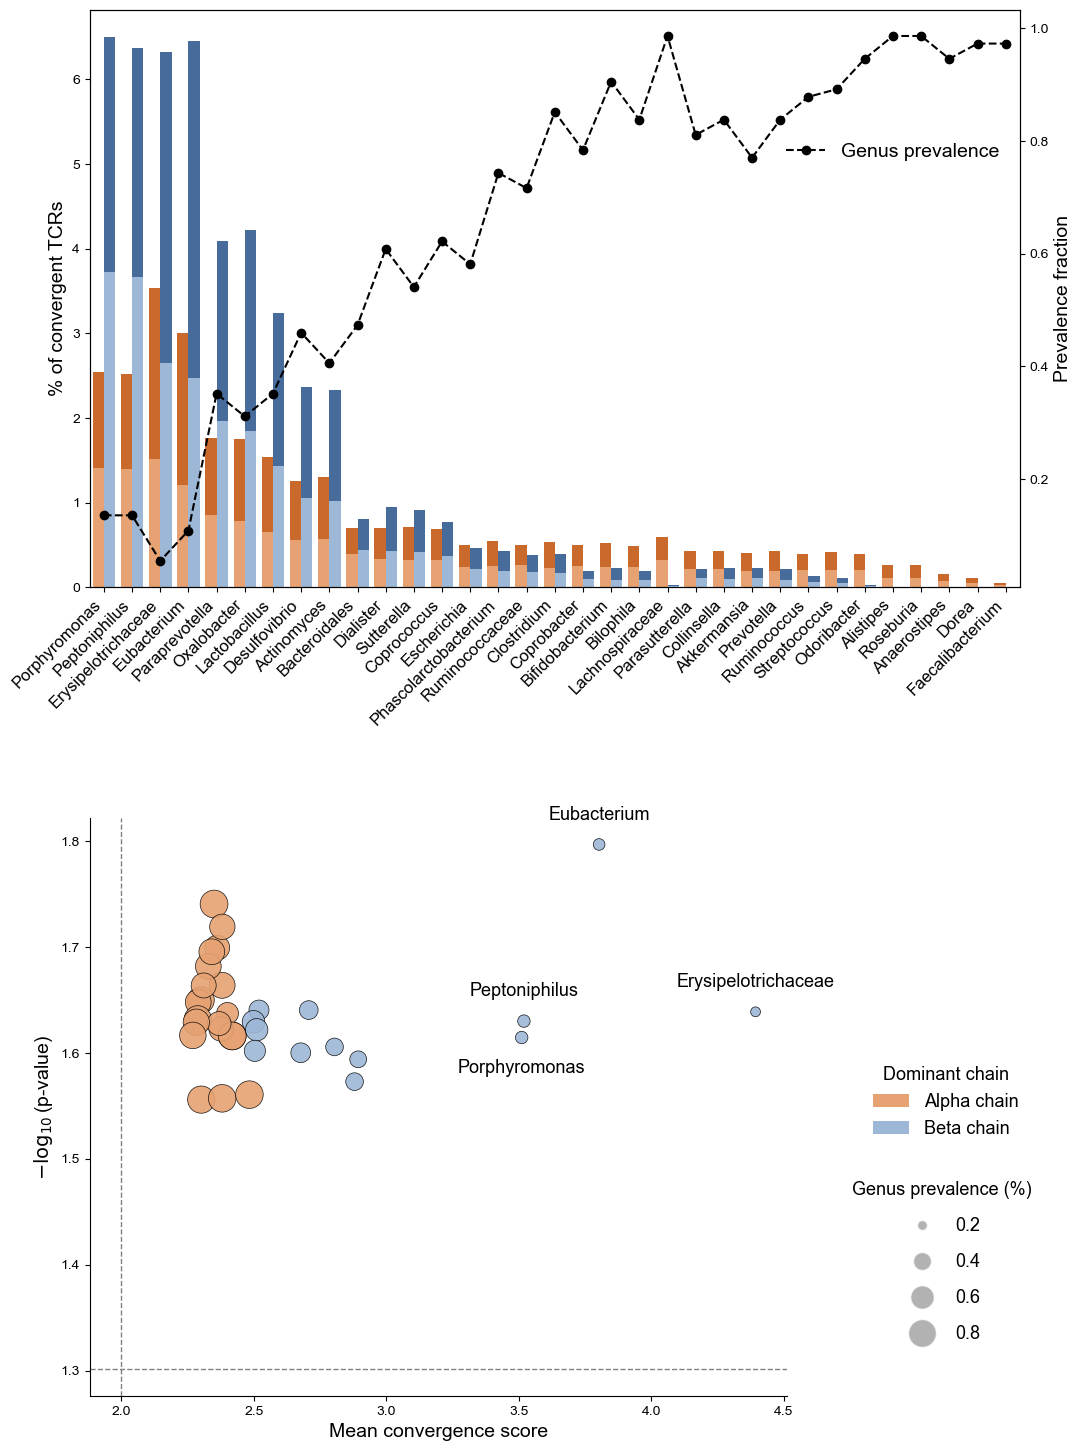

In [7]:
#########################
### Figure generation ###
#########################

# Figure parameters
sig_threshold = 0.05
conv_threshold = 2
chain_palette = {"TRA": "#e6a272", "TRB": "#9db7d6"}
custom_palette = {
    "TRA-CD4": "#e6a272",
    "TRB-CD4": "#9db7d6",
    "TRA-CD8": "#c96a2c",
    "TRB-CD8": "#476c9b",
}

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 18),
    gridspec_kw={"height_ratios": [1, 1], "hspace": 0.4},
    constrained_layout=True,
)

# Panel 1: Stacked barplot per chain-cell type groups and prevalence
ax1 = axes[0]
genus_labels = cell_group_summary["genus"]
x = np.arange(len(genus_labels))
width = 0.4

# Alpha chain bars
ax1.bar(
    x - width / 2,
    cell_group_summary["rel_TRA_CD4"],
    width,
    label="TRA-CD4",
    color=custom_palette["TRA-CD4"],
)
ax1.bar(
    x - width / 2,
    cell_group_summary["rel_TRA_CD8"],
    width,
    bottom=cell_group_summary["rel_TRA_CD4"],
    label="TRA-CD8",
    color=custom_palette["TRA-CD8"],
)

# Beta chain bars
ax1.bar(
    x + width / 2,
    cell_group_summary["rel_TRB_CD4"],
    width,
    label="TRB-CD4",
    color=custom_palette["TRB-CD4"],
)
ax1.bar(
    x + width / 2,
    cell_group_summary["rel_TRB_CD8"],
    width,
    bottom=cell_group_summary["rel_TRB_CD4"],
    label="TRB-CD8",
    color=custom_palette["TRB-CD8"],
)

ax1.set_xticks(x)
ax1.set_xticklabels(genus_labels, rotation=45, ha="right", size=12)
ax1.set_ylabel("% of convergent TCRs", fontsize=14)
ax1.set_xlim(x[0] - width - 0.1, x[-1] + width + 0.1)
ax1b = ax1.twinx()
ax1b.plot(
    x,
    cell_group_summary["genus_prevalence"],
    "--o",
    color="black",
    label="Genus prevalence",
)
ax1b.set_ylabel("Prevalence fraction", fontsize=14)

# No legend for cell types, only legend for genus prevalence
handles1, labels1 = ax1.get_legend_handles_labels()
order = ["TRA-CD4", "TRA-CD8", "TRB-CD4", "TRB-CD8"]
handle_dict = {label: handle for handle, label in zip(handles1, labels1)}
ordered_handles = [handle_dict[label] for label in order]
ordered_labels = order
handles2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(
    handles2,
    labels2,
    bbox_to_anchor=(0.73, 0.8),
    loc="upper left",
    fontsize=14,
    frameon=False,
)


# Panel 2: Volcano plot
ax2 = axes[1]
box = ax2.get_position()
ax2.set_position([box.x0, box.y0, box.width * 0.75, box.height])

sc = sns.scatterplot(
    data=convergence_summary,
    x="mean_convergence",
    y="neg_log10_p",
    hue="dominant_chain",
    size="Genus prevalence (%)",
    sizes=(50, 400),
    palette=chain_palette,
    alpha=0.9,
    edgecolor="black",
    linewidth=0.5,
    ax=ax2,
    legend=False,
)

# Threshold lines
ax2.axhline(-np.log10(sig_threshold), color="gray", linestyle="--", linewidth=1)
ax2.axvline(conv_threshold, color="gray", linestyle="--", linewidth=1)

# Top 4 annotations
top4 = convergence_summary.nlargest(4, "mean_convergence")
for i, (_, row) in enumerate(top4.iterrows()):
    y_offset = 0.02 if i != 3 else -0.02
    va = "bottom" if i != 3 else "top"
    ax2.text(
        row["mean_convergence"],
        row["neg_log10_p"] + y_offset,
        row["genus"],
        fontsize=13,
        ha="center",
        va=va,
    )

ax2.set_xlabel("Mean convergence score", fontsize=14)
ax2.set_ylabel(r"$-\log_{10}$(p-value)", fontsize=14)
sns.despine(ax=ax2)

# Legends, 2 separate legends, one for the chain type, one for size of the dots
hue_handles = [
    Patch(facecolor=chain_palette["TRA"]),
    Patch(facecolor=chain_palette["TRB"]),
]
hue_labels = ["Alpha chain", "Beta chain"]
leg1 = ax2.legend(
    hue_handles,
    hue_labels,
    title="Dominant chain",
    title_fontsize=13,
    fontsize=13,
    loc="upper left",
    bbox_to_anchor=(1.10, 0.60),
    frameon=False,
)

size_vals = [0.2, 0.4, 0.6, 0.8]
size_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="gray",
        markersize=np.interp(val, [0.2, 0.8], [50, 400]) ** 0.5,
        alpha=0.6,
    )
    for val in size_vals
]
size_labels = [str(val) for val in size_vals]

leg2 = ax2.legend(
    size_handles,
    size_labels,
    title="Genus prevalence (%)",
    title_fontsize=13,
    fontsize=13,
    loc="upper left",
    bbox_to_anchor=(1.07, 0.40),
    frameon=False,
    labelspacing=1,
)

ax2.add_artist(leg1)

plt.tight_layout()
plt.savefig(figures_dir / "1D_E_convergence_bars_volcano.pdf", bbox_inches="tight")
plt.show()

## Suppl. Mean convergence and publicity

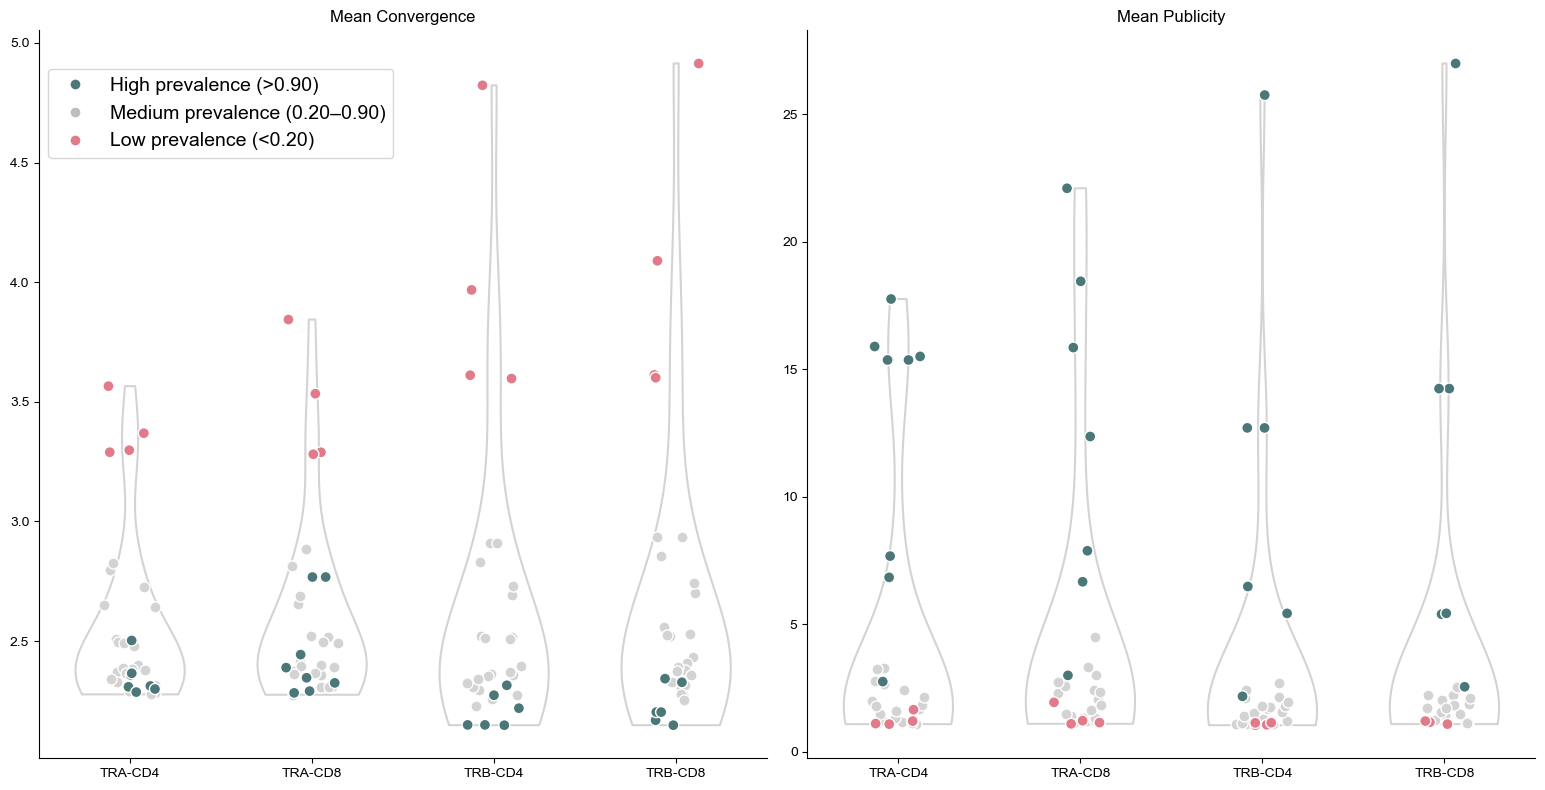

In [8]:
# Select which columns to plot for convergence
conv_cols = [
    "TRA_CD4_mean_convergence",
    "TRA_CD8_mean_convergence",
    "TRB_CD4_mean_convergence",
    "TRB_CD8_mean_convergence",
]

df_conv = cell_group_summary.melt(
    id_vars=["genus"],
    value_vars=conv_cols,
    var_name="Chain_Lineage",
    value_name="Mean_Convergence",
)
df_conv = df_conv[df_conv["Mean_Convergence"] != 0]
df_conv = df_conv.merge(
    cell_group_summary[["genus", "genus_prevalence"]], on="genus", how="left"
)
df_conv["prev_cat"] = df_conv["genus_prevalence"].apply(
    lambda x: "#E17A89" if x < 0.20 else ("#4C7778" if x > 0.90 else "#bebebc")
)

# Select which columns to plot for publicity
pub_cols = [
    "TRA_CD4_mean_publicity",
    "TRA_CD8_mean_publicity",
    "TRB_CD4_mean_publicity",
    "TRB_CD8_mean_publicity",
]

df_pub = cell_group_summary.melt(
    id_vars=["genus"],
    value_vars=pub_cols,
    var_name="Chain_Lineage",
    value_name="Mean_Publicity",
)
df_pub = df_pub[df_pub["Mean_Publicity"] != 0]
df_pub = df_pub.merge(
    cell_group_summary[["genus", "genus_prevalence"]], on="genus", how="left"
)
df_pub["prev_cat"] = df_pub["genus_prevalence"].apply(
    lambda x: "#E17A89" if x < 0.20 else ("#4C7778" if x > 0.90 else "#bebebc")
)


#########################
### Figure generation ###
#########################

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=False)

xtick_labels = {
    "TRA_CD4_mean_convergence": "TRA-CD4",
    "TRA_CD8_mean_convergence": "TRA-CD8",
    "TRB_CD4_mean_convergence": "TRB-CD4",
    "TRB_CD8_mean_convergence": "TRB-CD8",
    "TRA_CD4_mean_publicity": "TRA-CD4",
    "TRA_CD8_mean_publicity": "TRA-CD8",
    "TRB_CD4_mean_publicity": "TRB-CD4",
    "TRB_CD8_mean_publicity": "TRB-CD8",
}


# Panel 1: Mean Convergence
sample_violin_plot(
    ax=axes[0],
    df=df_conv,
    x="Chain_Lineage",
    y="Mean_Convergence",
    hue="prev_cat",
    palette={"#E17A89": "#E17A89", "#4C7778": "#4C7778"},
    xtick_labels=xtick_labels,
    title="Mean Convergence",
)


# Panel 2: Mean Publicity
sample_violin_plot(
    ax=axes[1],
    df=df_pub,
    x="Chain_Lineage",
    y="Mean_Publicity",
    hue="prev_cat",
    palette={"#E17A89": "#E17A89", "#4C7778": "#4C7778"},
    xtick_labels=xtick_labels,
    title="Mean Publicity",
)


# Legend
legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="#4C7778",
        markersize=8,
        label="High prevalence (>0.90)",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="#bebebc",
        markersize=8,
        label="Medium prevalence (0.20–0.90)",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="#E17A89",
        markersize=8,
        label="Low prevalence (<0.20)",
    ),
]

axes[0].legend(
    handles=legend_elements,
    fontsize=14,
    frameon=True,
    loc="upper right",
    bbox_to_anchor=(0.5, 0.96),
)

plt.tight_layout()
plt.savefig(suppl_dir / "S1_mean_conv_publicity.pdf", bbox_inches="tight")
plt.show()

# 2. Interaction network

Create the TCR-microbiome interaction network dataframe and html file

In [1]:
from pathlib import Path
import pandas as pd
import networkx as nx
from pyvis.network import Network
import community as community_louvain

import matplotlib.cm as cm
from collections import Counter

import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

In [2]:
# Base directory of the files
base_dir = Path("..").resolve()

# Directories containing the processed files
processed_dir = base_dir / "2_processed_data" / "3_discovery_convergence"
conv_dir = base_dir / "2_processed_data" / "6_combined_convergence"

# Output directories for the figures and tables
figures_dir = base_dir / "3_figures" / "Figures"
tables_dir = base_dir / "3_figures" / "Tables"
suppl_dir = base_dir / "3_figures" / "Supplementary"

In [3]:
# Load all significantly convergent results and select only the discovery dataset results
final_conv = pd.read_csv(
    conv_dir / "0_combined_final_sign_interactions.csv",
    index_col=0,
)
conv_disc = final_conv[
    (final_conv["dataset"] == "Discovery")
    & (final_conv["convergence"] > 2)
    & (final_conv["pvalue"] <= 0.05)
]
conv_disc["chain"] = conv_disc["v_call"].str.extract(r"(TR[A|B])")

# Calculate how in how many patients a VDJ TCR is linked to the same genus
tcr_patient_counts = (
    final_conv.groupby(["junction_aa", "v_call", "j_call"])["patient_id"]
    .nunique()
    .reset_index()
    .rename(columns={"patient_id": "patient_count"})
)

conv_disc = conv_disc.merge(
    tcr_patient_counts, on=["junction_aa", "v_call", "j_call"], how="left"
)

# Create the network dataframe for public TCRs, so CDR3s present in 4 indivuals or more
network_df = conv_disc[
    [
        "junction_aa",
        "v_call",
        "j_call",
        "chain",
        "genus",
        "convergence",
        "patient_count",
    ]
].drop_duplicates()
network_df = network_df[network_df["patient_count"] > 4]

# Add node IDs to each unique TCR and genus
new_df = pd.concat([network_df["junction_aa"], network_df["genus"]])
unique = len(new_df.unique())
df = pd.DataFrame()
df["node_id"] = range(1, unique + 1, 1)
df["node_name"] = new_df.unique()
dictionary = df.set_index("node_name").to_dict()["node_id"]

network_df["node_id_var1"] = network_df["junction_aa"]
network_df["node_id_var2"] = network_df["genus"]
network_df = network_df.replace({"node_id_var1": dictionary})
network_df = network_df.replace({"node_id_var2": dictionary})
network_df

,junction_aa,v_call,j_call,chain,genus,convergence,patient_count,node_id_var1,node_id_var2
2208,CVVTDSYNQGGKLIF,TRAV12-1*01,TRAJ23*01,TRA,Desulfovibrio,2.345974,5,1,3458
2910,CGADTGRRALTF,TRAV34*01,TRAJ5*01,TRA,Desulfovibrio,2.247471,7,2,3458
2943,CGADISNFGNEKLTF,TRAV34*01,TRAJ48*01,TRA,Desulfovibrio,2.415790,8,3,3458
2944,CGAGGATNKLIF,TRAV34*01,TRAJ32*01,TRA,Desulfovibrio,2.306359,5,4,3458
3134,CAVPLGGANSKLTF,TRAV21*01,TRAJ56*01,TRA,Desulfovibrio,2.107968,5,5,3458
...,...,...,...,...,...,...,...,...,...
1113293,CAAGMGLAGNTGELFF,TRBV27*01,TRBJ2-2*01,TRB,Peptoniphilus,3.287033,5,3440,3490
1115237,CASSETTSGSTDTQYF,TRBV27*01,TRBJ2-3*01,TRB,Peptoniphilus,2.016844,6,3455,3490
1115532,CASRRPTGFQYF,TRBV27*01,TRBJ2-3*01,TRB,Peptoniphilus,2.665694,5,1565,3490
1127776,CASRQVGETQYF,TRBV19*01,TRBJ2-5*01,TRB,Peptoniphilus,2.716823,5,3456,3490


In [4]:
# Create the graph based on the nodes identified in network df
# Apply louvain community method to identify which nodes are more connected to each other than to the rest of the network
G = nx.Graph()
for a, b in zip(network_df["junction_aa"], network_df["genus"]):
    G.add_edge(a, b)

partition = community_louvain.best_partition(G)

# For readability, select on the top 20 largest communities and put everything else in a "Other" group
# Give each of the top 20 communities their own color
community_sizes = Counter(partition.values())
top_20_communities = {cid for cid, _ in community_sizes.most_common(20)}

partition_limited = {}
for node, cid in partition.items():
    if cid in top_20_communities:
        partition_limited[node] = cid
    else:
        partition_limited[node] = -1

num_colors = len(top_20_communities)
cmap = cm.get_cmap("tab20", num_colors)
community_id_to_color_index = {
    cid: i for i, cid in enumerate(sorted(top_20_communities))
}

community_colors = {}
for node, cid in partition_limited.items():
    if cid == -1:
        community_colors[node] = "#cccccc"
    else:
        rgb = cmap(community_id_to_color_index[cid])[:3]
        community_colors[node] = "#%02x%02x%02x" % tuple([int(255 * c) for c in rgb])

# Map nodes to communities
network_df["community"] = network_df["junction_aa"].map(partition_limited)
network_df["community"] = network_df["community"].replace({-1: "Other"})

network_df.to_csv(processed_dir / "Network_dataframe.csv")
network_df

,junction_aa,v_call,j_call,chain,genus,convergence,patient_count,node_id_var1,node_id_var2,community
2208,CVVTDSYNQGGKLIF,TRAV12-1*01,TRAJ23*01,TRA,Desulfovibrio,2.345974,5,1,3458,3
2910,CGADTGRRALTF,TRAV34*01,TRAJ5*01,TRA,Desulfovibrio,2.247471,7,2,3458,3
2943,CGADISNFGNEKLTF,TRAV34*01,TRAJ48*01,TRA,Desulfovibrio,2.415790,8,3,3458,3
2944,CGAGGATNKLIF,TRAV34*01,TRAJ32*01,TRA,Desulfovibrio,2.306359,5,4,3458,3
3134,CAVPLGGANSKLTF,TRAV21*01,TRAJ56*01,TRA,Desulfovibrio,2.107968,5,5,3458,3
...,...,...,...,...,...,...,...,...,...,...
1113293,CAAGMGLAGNTGELFF,TRBV27*01,TRBJ2-2*01,TRB,Peptoniphilus,3.287033,5,3440,3490,3
1115237,CASSETTSGSTDTQYF,TRBV27*01,TRBJ2-3*01,TRB,Peptoniphilus,2.016844,6,3455,3490,3
1115532,CASRRPTGFQYF,TRBV27*01,TRBJ2-3*01,TRB,Peptoniphilus,2.665694,5,1565,3490,1
1127776,CASRQVGETQYF,TRBV19*01,TRBJ2-5*01,TRB,Peptoniphilus,2.716823,5,3456,3490,3


In [ ]:
################################
### Create the Pyvis network ###
################################
pos = nx.spring_layout(G, seed=42)

net = Network(
    notebook=True,
    height="2000px",
    width="100%",
    select_menu=False,
    filter_menu=False,
    cdn_resources="remote",
    font_color="black",
)

for a, b, c, d, e in zip(
    network_df["node_id_var1"],
    network_df["junction_aa"],
    network_df["node_id_var2"],
    network_df["genus"],
    network_df["chain"],
):

    # Color the nodes by community
    tcr_color = community_colors[b] if b in community_colors else "#cccccc"
    genus_color = community_colors[d] if d in community_colors else "#cccccc"

    net.add_node(a, label="", color=tcr_color, shape="dot", size=50)
    net.add_node(c, label=d, color=genus_color, shape="box")
    net.add_edge(a, c, color="gray", physics=True)

genus_ids = [dictionary[genus] for genus in network_df["genus"].unique()]
for n in net.nodes:
    if n["id"] in genus_ids:
        n["font"] = {"size": 120}

# Physics settings
net.barnes_hut(
    gravity=-80000,
    central_gravity=0,
    spring_length=400,
    spring_strength=0.05,
    damping=0.09,
    overlap=0,
)

net.show(str(figures_dir / "1F_network_community.html"))

In [6]:
# Degree dictionary for genus nodes
degree_dict = dict(G.degree())
genus_nodes = network_df["genus"].unique()
genus_degrees = {g: degree_dict[g] for g in genus_nodes if g in degree_dict}

# Sort and take top 3
top3_direct = sorted(genus_degrees.items(), key=lambda x: x[1], reverse=True)[:3]
print("Top 3 genus nodes by direct TCR connections:")
for genus, deg in top3_direct:
    print(genus, ":", deg, "TCRs")


two_step_counts = {}

for genus in genus_nodes:
    if genus not in G:
        continue
    tcr_neighbors = set(G.neighbors(genus))
    connected_genera = set()
    for tcr in tcr_neighbors:
        neighbors = set(G.neighbors(tcr))
        # Only count other genera, not TCRs
        connected_genera.update([n for n in neighbors if n in genus_nodes])
    connected_genera.discard(genus)
    two_step_counts[genus] = len(connected_genera)


# Sort and take top 3
top3_indirect = sorted(two_step_counts.items(), key=lambda x: x[1], reverse=True)[:3]
print("Top 3 genus nodes by indirect genus connections through TCRs:")
for genus, count in top3_indirect:
    print(genus, ":", count, "other genera")


community_values = list(partition.values())

num_communities = len(set(community_values))
print("Number of communities:", num_communities)

community_sizes = Counter(community_values)
for community_id, size in community_sizes.items():
    print(f"Community {community_id}: {size} nodes")

Top 3 genus nodes by direct TCR connections:
Lachnospiraceae : 493 TCRs
Erysipelotrichaceae : 432 TCRs
Odoribacter : 368 TCRs
Top 3 genus nodes by indirect genus connections through TCRs:
Erysipelotrichaceae : 23 other genera
Coprobacter : 21 other genera
Parasutterella : 21 other genera
Number of communities: 18
Community 3: 191 nodes
Community 16: 65 nodes
Community 10: 142 nodes
Community 5: 184 nodes
Community 1: 118 nodes
Community 11: 179 nodes
Community 8: 152 nodes
Community 12: 348 nodes
Community 14: 193 nodes
Community 17: 194 nodes
Community 2: 26 nodes
Community 4: 355 nodes
Community 13: 275 nodes
Community 6: 189 nodes
Community 7: 100 nodes
Community 9: 58 nodes
Community 15: 245 nodes
Community 0: 476 nodes
